In [ ]:
# Importo librerias necesarias para poder leer mis archivos CSV y tambien para ahcer las primeras visualizaciones

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DATASET IDS_mapping.csv

df_map = pd.read_csv('IDS_mapping.csv')
df_map.info()
df_map.head(40)
#df_map.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


El dataset IDS_mapping.csv tiene 67 filas y 2 columnas.
Es una Lista de Indices y descripciones.
Hay tres indices distintos:
- admission_type_id
- discharge_disposition_id
- admission_source_id
Tiene bastante proporcion de datos nulos.

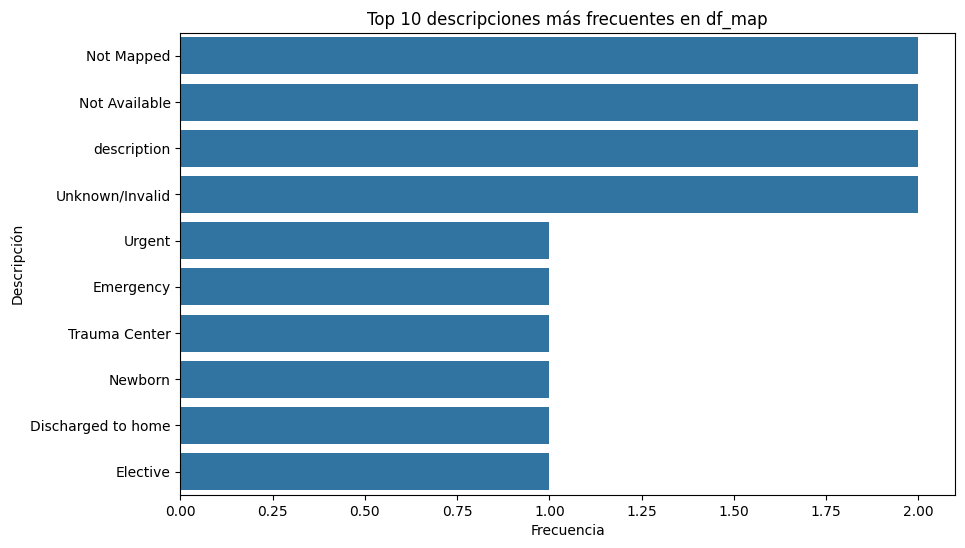

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(
    y='description',
    data=df_map,
    order=df_map['description'].value_counts().head(10).index
)
plt.title('Top 10 descripciones más frecuentes en df_map')
plt.xlabel('Frecuencia')
plt.ylabel('Descripción')
plt.show()


In [ ]:
# DATASET diabetic_data.csv

df_data = pd.read_csv('diabetic_data.csv')
df_data.info()
df_data.head(10)
df_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


El dataset diabetic_data.csv tiene 101766 filas y 50 columnas.
Contiene informacion sobre pacientes que ingresaron al hospital, donde cada fila corresponde a una internacion de paciente.
No contiene datos nulos salvo:
weight:  casi todo "?"
max_glu_serum: solo 5% con datos
A1Cresult: solo aprox 17%

Columnas relevantes para los objetivos:
*Demográficas*
race
gender
age
weight: casi todo '?', se puede ignorar

*Hospitalización / resultado*
time_in_hospital
readmitted (NO, >30, <30)
discharge_disposition_id

*Tratamiento*
insulin
change
diabetesMed
muchas columnas con medicamentos aplicados que servirian para un analisis exhaustivo respecto de que tratamiento funciona mejor segun si el paciente es o no reingresado.

*Contexto*
num_medications
number_inpatient
number_emergency
admission_type_id
admission_source_id

In [ ]:
####### Factor tiempo de hospitalizacion #######

df_data['time_in_hospital'].describe()


####### Factor reingreso ########

df_data['readmitted'].value_counts(normalize=True)


####### Factores demograficos #######

# Cuantas razas existen?
df_data['race'].value_counts()

# Cuantas generos existen?
df_data['gender'].value_counts()

# Cuantas razas existen?
df_data['race'].value_counts()


# Veo el tiempo promedio en el que estuvo en el hospital cada rango etario (agrupada por edad)
df_data.groupby('age')['time_in_hospital'].mean()

# Veo el tiempo promedio en el que estuvo en el hospital segun la variable race
df_data.groupby('race')['time_in_hospital'].mean()

# Veo el tiempo promedio en el que estuvo en el hospital segun la variable gender
df_data.groupby('gender')['time_in_hospital'].mean()


,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641


De manera exploratoria, se observan diferencias en el tiempo promedio de hospitalización entre distintos grupos demográficos; sin embargo, estos resultados deben interpretarse con cautela debido a la presencia de valores atípicos y variables con ruido
Algunas primeras conclusiones:
El tiempo promedio de hospitalizacion es de 4.39 dias por paciente segun el describe de la variable 'time_in_hospital'.
El 53% de los pacientes no fueron readmitidos segun el value_counts de 'readmitted'.
La mayoría:
no tuvo emergencias previas y
no tuvo internaciones previas.
Hay algunos outliers (internaciones largas, muchas emergencias).
Cuando hago el tiempo en hospital medio segun el genero, me doy cuenta que hay una categoria "Unknown/ Invalid" que tendria que ver de que se trata.
Las diferentes razas tienen una categoria '?' que elijo eliminar.




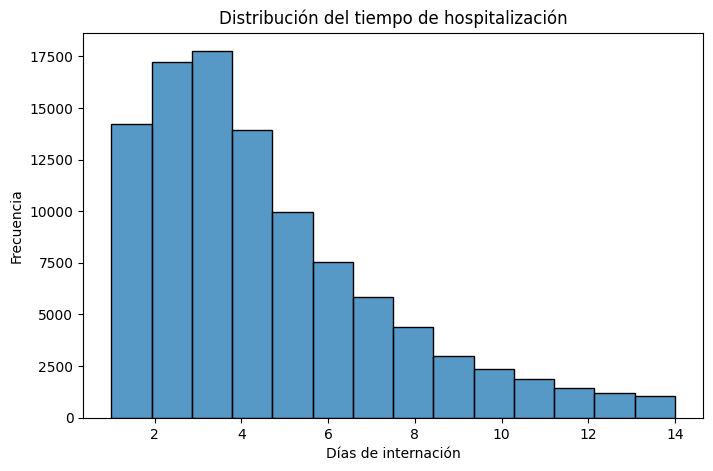

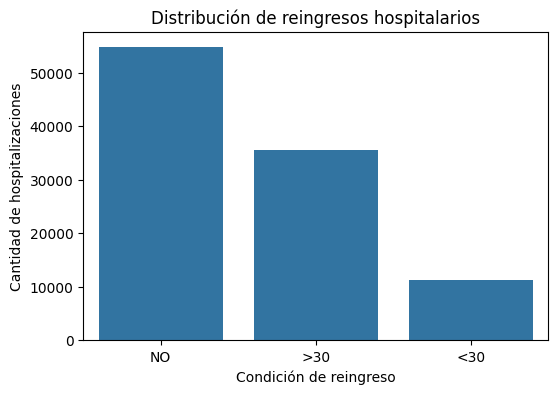

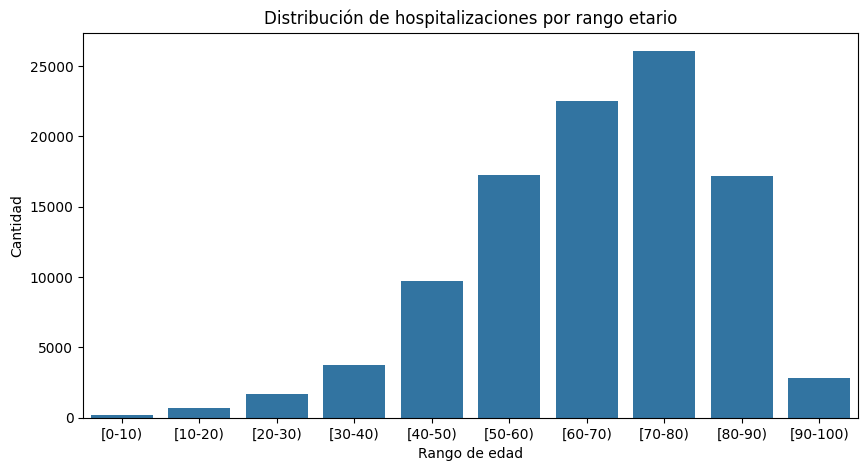

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de tiempo de hospitalizacion
plt.figure(figsize=(8,5))
sns.histplot(df_data['time_in_hospital'], bins=14)
plt.title('Distribución del tiempo de hospitalización')
plt.xlabel('Días de internación')
plt.ylabel('Frecuencia')
plt.show()

# Grafico de Barras de reingresos hospitalarios
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df_data)
plt.title('Distribución de reingresos hospitalarios')
plt.xlabel('Condición de reingreso')
plt.ylabel('Cantidad de hospitalizaciones')
plt.show()

# Grafico de barras por rango etario
plt.figure(figsize=(10,5))
sns.countplot(
    x='age',
    data=df_data,
    order=sorted(df_data['age'].unique()))
plt.title('Distribución de hospitalizaciones por rango etario')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad')
plt.show()


Histograma de tiempo de hospitalizacion
Muestra la distribucion de la variable por la frecuencia de los diferentes valores. La mayoria de los pacientes estuvo internado entre 1 y 6 dias, con maximos en 2 y 3. La variable no es simétrica y hay muchos casos cortos y pocos largos. Siguen apareciendo internaciones hasta de 14 dias pero con mucha menor frecuencia.

Grafico de Barras de reingresos hospitalarios
Aca tambien podemos ver graficamente que la mayoria de los pacientes no fuerpn readmitidos (en el grafico de barras de 'readmitted') Dataset desbalanceado. Reingreso es un evento menos frecuente Esto justifica:
analizar proporciones y no sacar conclusiones fuertes sin segmentar.

Por ultimo, segun el grafico de cantidad de internaciones por el rango de edad, podemos observar que la mayoria de los pacientes tienen entre 50 y 90 anios, mas pronunciado de 60-80.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

,count
num_lab_procedures,
1,3146
43,2750
44,2448
45,2328
38,2164
...,...
120,1
132,1
121,1


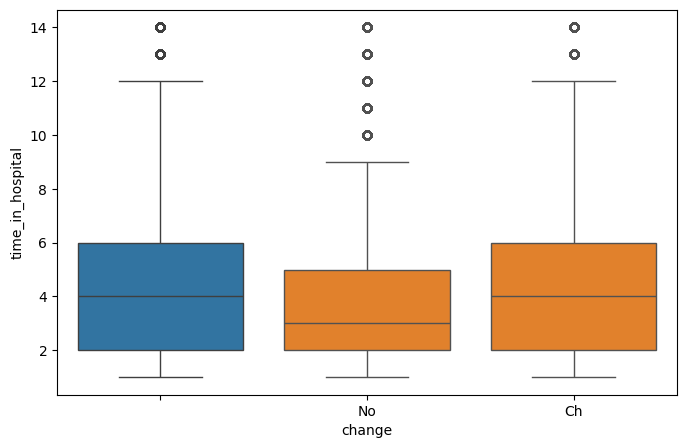

In [ ]:
# LIMPIEZA df_data


(df_data == '?').mean().sort_values(ascending=False)
df_data.isnull().mean().sort_values(ascending=False)

# Elimino columas que no me sirven
df_data_clean = df_data.drop(
    columns=['weight', 'payer_code', 'medical_specialty','max_glu_serum','A1Cresult']
)

# Chequeo que se borraron
df_data_clean.columns
df_data_clean.info()

# Otros datos nulos
# Elimino los valores nulos en la variable race y gender.
df_data_clean = df_data_clean[df_data_clean['race'] != '?']
df_data_clean['gender'].value_counts()
df_data_clean.drop(
   df_data_clean[df_data_clean['gender'] == 'Unknown/Invalid'].index
)

df_data_clean.isnull().sum().sort_values(ascending=False)


# Veo outliers de cada variable que me interese:
# time_in_hospital
plt.figure(figsize=(8,5))
sns.boxplot(df_data_clean['time_in_hospital'])

#



# Calculo la media de tiempo en hospital segun si cambiaron o no de medicacion.
df_data_clean.groupby('change')['time_in_hospital'].mean()


# Visualizo los resultados con un boxplot
sns.boxplot(
    x='change',
    y='time_in_hospital',
    data=df_data_clean
)






# Que tipo de valores hay aca?

df_data_clean['number_diagnoses'].value_counts()
df_data_clean['num_procedures'].value_counts()
df_data_clean['num_medications'].value_counts()
df_data_clean['num_lab_procedures'].value_counts()



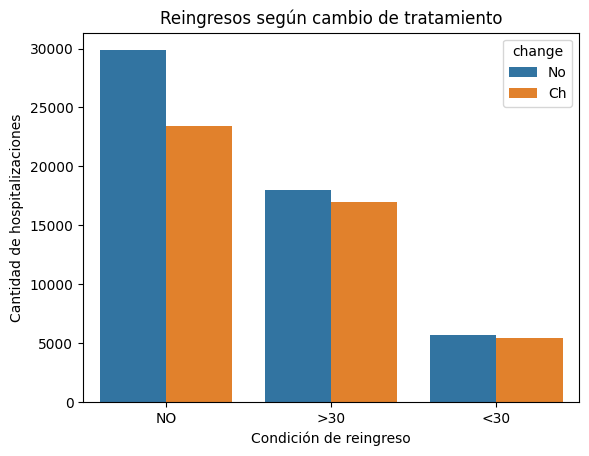

In [ ]:
# Analizo la influencia de cambiar el tratamiento con si fue o no readmitido el paciente.
# Borro registros nulos.
# Visualizo esa influencia con un boxplot
pd.crosstab(
    df_data_clean['change'],
    df_data_clean['readmitted']
)

df_data_clean = df_data_clean.dropna(subset=['readmitted'])
df_data_clean.isnull().sum()

order = ['NO', '>30', '<30']

sns.countplot(
    x='readmitted',
    hue='change',
    data=df_data_clean,
    order=order
)

plt.title('Reingresos según cambio de tratamiento')
plt.xlabel('Condición de reingreso')
plt.ylabel('Cantidad de hospitalizaciones')
plt.show()


LIMPIEZA

Como casi todo el porcentaje de 'weight' es nulo, voy a borrar directamente la columna.
'medical_specialty' tiene casi la mitad de nulos, asi que tambien voy a eliminarla.
Y por ultimo, voy a hacer lo mismo con 'payer_code', que si bien muestra informacion valiosa de quien paga el tratamiento del paciente, esta bastante incompleta (aprox 39%) o los datos son inconsistentes.
Tambien voy a borrar max_glu_serum (aprox 95% datos nulos)
y A1Cresult (83%).
Elimine '?' en la variable race, ya que solo constituia el 2% de los registros de esa columna.data
Se eliminaron los registros con valores inválidos en la variable género, dado que representaban una proporción insignificante del total de observaciones.

VISUALIZACIONES PRELIMINARES

Segun el boxplot de 'time_in_hospital' los valores que aparecen como outliers no son errores: son internaciones largas pero plausibles ya que el dataset define el máximo en 14.
Agrupe las hospitalizaciones según si hubo cambio de tratamiento (change)
y calcule el promedio del tiempo de internación en cada grupo. Se observa que los pacientes cuyo tratamiento fue modificado durante la hospitalización presentan, en promedio, una mayor duración de internación.
Se observa que los pacientes con modificaciones en el tratamiento (CH) presentan una mayor proporción de reingresos en comparación con aquellos sin cambios.


In [ ]:
df_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99493 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              99493 non-null  int64 
 1   patient_nbr               99493 non-null  int64 
 2   race                      99493 non-null  object
 3   gender                    99493 non-null  object
 4   age                       99493 non-null  object
 5   admission_type_id         99493 non-null  int64 
 6   discharge_disposition_id  99493 non-null  int64 
 7   admission_source_id       99493 non-null  int64 
 8   time_in_hospital          99493 non-null  int64 
 9   num_lab_procedures        99493 non-null  int64 
 10  num_procedures            99493 non-null  int64 
 11  num_medications           99493 non-null  int64 
 12  number_outpatient         99493 non-null  int64 
 13  number_emergency          99493 non-null  int64 
 14  number_inpatient          

In [ ]:
# LIMPIEZA PARA df_map

# Copia del dataframe original
df_map_clean = df_map.copy()

# Eliminamos filas completamente nulas
df_map_clean = df_map_clean.dropna(how='all')

# Nos quedamos solo con filas donde el ID sea numérico
df_map_clean = df_map_clean[
    df_map_clean['admission_type_id'].astype(str).str.isnumeric()
]

# Eliminamos categorías genéricas o no informativas
df_map_clean = df_map_clean[
    ~df_map_clean['description'].isin(['Not Mapped', 'Not Available', 'Unknown/Invalid'])
]

# Eliminamos nulos restantes
df_map_clean = df_map_clean.dropna()

# Conversión segura de tipos
df_map_clean['admission_type_id'] = df_map_clean['admission_type_id'].astype(int)

# Division de indices y reset:

def split_mapping_tables(df):
    tablas = {}
    tabla_actual = None
    filas = []

    for _, row in df.iterrows():
        valor = row.iloc[0]

        # Si encontramos un nuevo bloque
        if valor in [
            'admission_type_id',
            'discharge_disposition_id',
            'admission_source_id'
        ]:
            if tabla_actual is not None:
                tablas[tabla_actual] = pd.DataFrame(
                    filas, columns=df.columns
                )

            tabla_actual = valor
            filas = []
            continue


        # Si estamos dentro de un bloque, guardamos filas válidas
        if tabla_actual is not None:
            filas.append(row)

    # Guardamos el último bloque
    if tabla_actual is not None:
        tablas[tabla_actual] = pd.DataFrame(
            filas, columns=df.columns
        )

    # Limpieza final de cada tabla
    for k, v in tablas.items():
        v.dropna(inplace=True)
        v = v[
            ~v['description'].isin(
                ['Not Mapped', 'Not Available', 'Unknown/Invalid']
            )
        ]
        v.iloc[:, 0] = v.iloc[:, 0].astype(int)
        tablas[k] = v.reset_index(drop=True)

    return tablas

tablas.keys()



#df_map_clean.head(30)
#df_map_clean.info()
#df_map_clean.isnull().sum()



dict_keys(['discharge_disposition_id', 'admission_source_id'])

Como este dataset tiene tres indices posibles diferentes.
admission_type_id: cómo entra el paciente,
discharge_disposition_id: cómo sale el paciente,
admission_source_id: desde dónde viene.

Las variables categóricas codificadas mediante identificadores fueron desacopladas en tablas diccionario independientes, preservando su semántica clínica y evitando la mezcla de conceptos distintos como ingreso, origen y tipo de alta. Hice la separacion de variables segun la columna ID, los separe en tres diferentes df.
Dado que el archivo de mapeo no presentaba una estructura tabular estándar y contenía múltiples diccionarios concatenados verticalmente, se implementó una función personalizada para separar cada bloque semántico en tablas independientes.

In [ ]:
df_admission_type = (
    df_map_clean
    .loc[df_map_clean['admission_type_id'].notna()]
    [['admission_type_id', 'description']]
    .drop_duplicates()
    .sort_values('admission_type_id')
    .reset_index(drop=True)
)
df_admission_type.head(10)



df_admission_source = (
    df_map_clean
    .loc[df_map_clean['admission_source_id'].notna()]
    [['admission_source_id', 'description']]
    .drop_duplicates()
    .sort_values('admission_source_id')
    .reset_index(drop=True)
)

df_discharge_disposition = (
    df_map_clean
    .loc[df_map_clean['discharge_disposition_id'].notna()]
    [['discharge_disposition_id', 'description']]
    .drop_duplicates()
    .sort_values('discharge_disposition_id')
    .reset_index(drop=True)
)

In [ ]:
# TRANSFORMACION DE df_data

import numpy as np


# Preparación de la variable 'age' como categórica ordenada
age_order = sorted(df_data_clean['age'].dropna().unique())
df_data_clean['age'] = pd.Categorical(
    df_data_clean['age'],
    categories=age_order,
    ordered=True
)

# Creación de variable binaria de reingreso
df_data_clean['readmitted_binary'] = df_data_clean['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

# Simplificación del uso de insulina
df_data_clean['insulin_used'] = df_data_clean['insulin'].apply(
    lambda x: 0 if x == 'No' else 1
)

df_data_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 99493 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   encounter_id              99493 non-null  int64   
 1   patient_nbr               99493 non-null  int64   
 2   race                      99493 non-null  object  
 3   gender                    99493 non-null  object  
 4   age                       99493 non-null  category
 5   admission_type_id         99493 non-null  int64   
 6   discharge_disposition_id  99493 non-null  int64   
 7   admission_source_id       99493 non-null  int64   
 8   time_in_hospital          99493 non-null  int64   
 9   num_lab_procedures        99493 non-null  int64   
 10  num_procedures            99493 non-null  int64   
 11  num_medications           99493 non-null  int64   
 12  number_outpatient         99493 non-null  int64   
 13  number_emergency          99493 non-null  int64   

In [ ]:
df_data_clean.head(30)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone_bin,tolazamide_bin,examide_bin,citoglipton_bin,insulin_bin,glyburide-metformin_bin,glipizide-metformin_bin,glimepiride-pioglitazone_bin,metformin-rosiglitazone_bin,metformin-pioglitazone_bin
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,0,0,0,0,0,0,0,0,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,0,0,0,0,1,0,0,0,0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,0,0,0,0,0,0,0,0,0,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,0,0,0,0,1,0,0,0,0,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,0,0,0,0,1,0,0,0,0,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,0,0,0,0,1,0,0,0,0,0
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,70,...,0,0,0,0,1,0,0,0,0,0
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,73,...,0,0,0,0,0,0,0,0,0,0
8,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,68,...,0,0,0,0,1,0,0,0,0,0
9,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,33,...,0,0,0,0,1,0,0,0,0,0


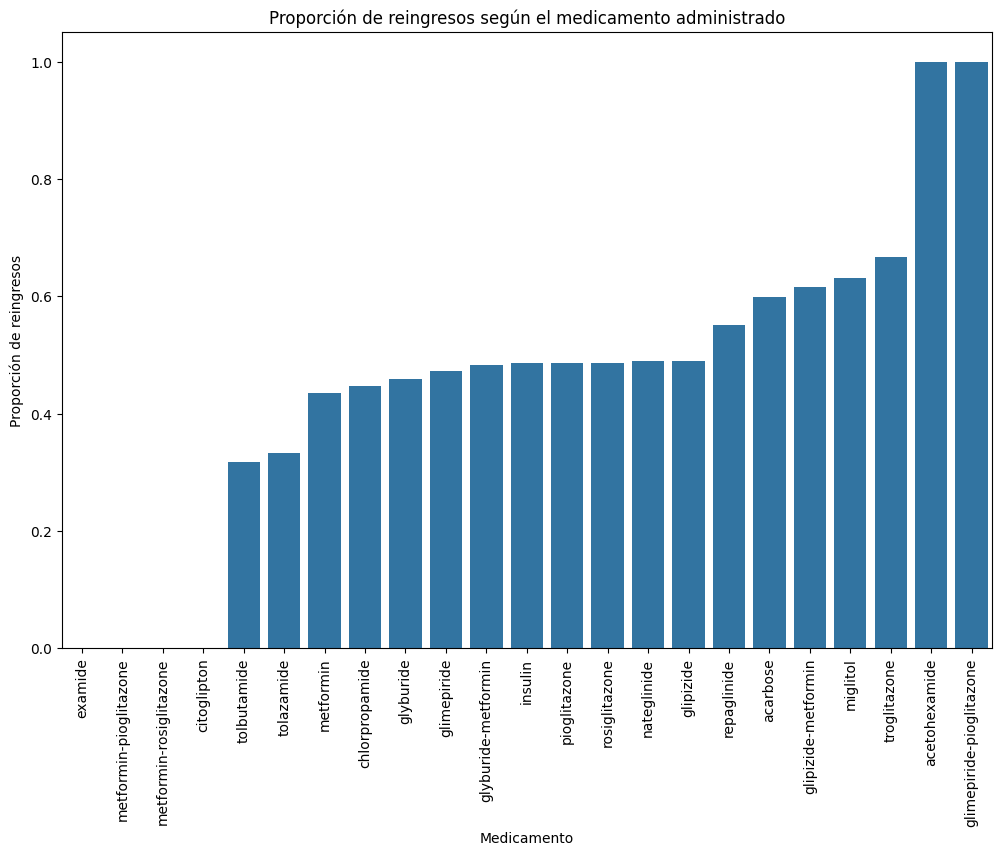

In [ ]:
# Lista de medicamentos a analizar
medicamentos = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]

# Crear un dataframe con proporción de reingresos por medicamento
proporcion_reingreso = {}
for med in medicamentos:
    # Convertimos cualquier valor diferente a 'No' en Sí
    df_data_clean[med+'_bin'] = df_data_clean[med].apply(lambda x: 0 if x=='No' else 1)
    proporcion_reingreso[med] = df_data_clean.groupby(med+'_bin')['readmitted_binary'].mean()[1] if 1 in df_data_clean[med+'_bin'].unique() else 0

# Convertir a dataframe para graficar
import pandas as pd
df_reingreso = pd.DataFrame.from_dict(proporcion_reingreso, orient='index', columns=['proporcion_reingreso'])
df_reingreso = df_reingreso.sort_values('proporcion_reingreso', ascending=True)

# Gráfico de barras
plt.figure(figsize=(12,8))
sns.barplot(x=df_reingreso.index, y='proporcion_reingreso', data=df_reingreso)
plt.xticks(rotation=90)
plt.ylabel('Proporción de reingresos')
plt.xlabel('Medicamento')
plt.title('Proporción de reingresos según el medicamento administrado')
plt.show()


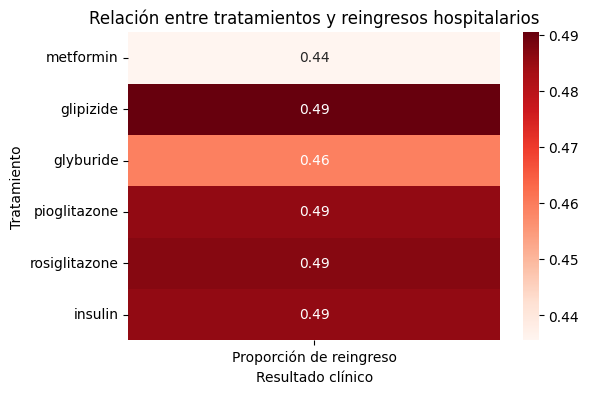

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos tratamientos clave
tratamientos = [
    'metformin',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'rosiglitazone',
    'insulin'
]

# Crear dataframe para el heatmap
heatmap_data = {}

for med in tratamientos:
    # Binario: 1 si recibió el medicamento, 0 si no
    df_data_clean[med + '_bin'] = df_data_clean[med].apply(lambda x: 0 if x == 'No' else 1)

    # Proporción de reingresos cuando el medicamento fue utilizado
    heatmap_data[med] = df_data_clean[df_data_clean[med + '_bin'] == 1]['readmitted_binary'].mean()

# Convertimos a DataFrame
df_heatmap = pd.DataFrame.from_dict(heatmap_data, orient='index', columns=['Proporción de reingreso'])

# Gráfico heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df_heatmap, annot=True, cmap='Reds', fmt='.2f')
plt.title('Relación entre tratamientos y reingresos hospitalarios')
plt.ylabel('Tratamiento')
plt.xlabel('Resultado clínico')
plt.show()


/tmp/ipython-input-1651784006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age', y='time_in_hospital', data=df_data_clean, palette='Set2')


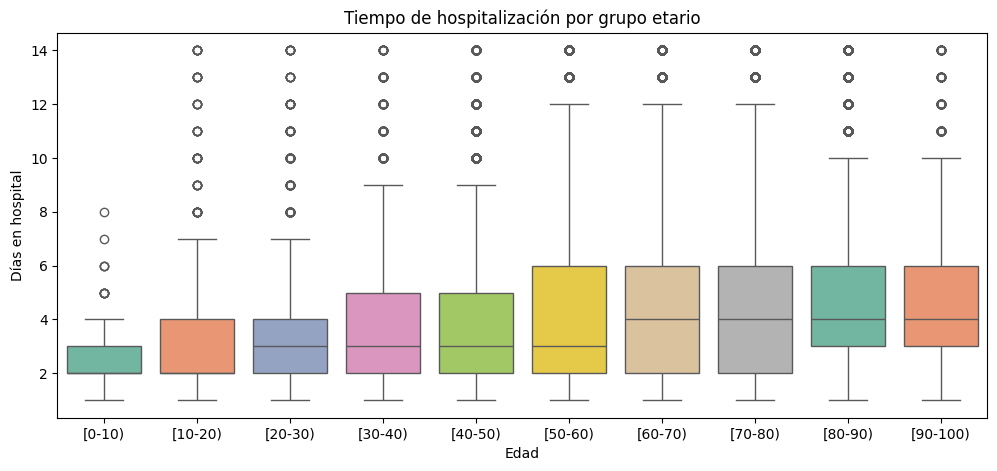

/tmp/ipython-input-1651784006.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='time_in_hospital', data=df_data_clean, palette='Set3')


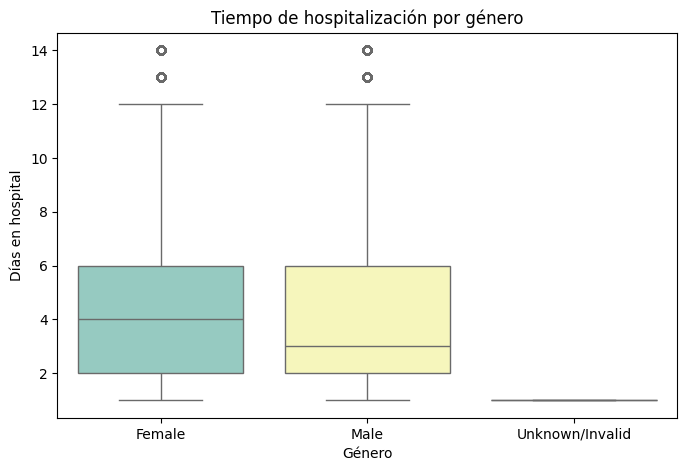

/tmp/ipython-input-1651784006.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='lab_bins', y='time_in_hospital', data=df_data_clean, palette='muted')


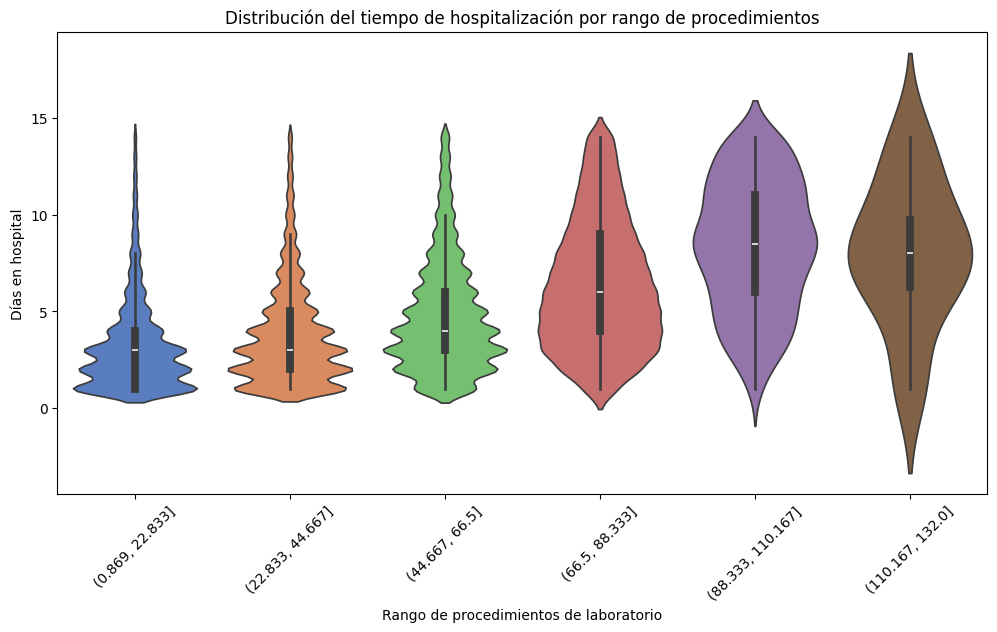

In [ ]:
# Queremos ver si edad, género o raza afectan el tiempo en el hospital.

plt.figure(figsize=(12,5))
sns.boxplot(x='age', y='time_in_hospital', data=df_data_clean, palette='Set2')
plt.title('Tiempo de hospitalización por grupo etario')
plt.xlabel('Edad')
plt.ylabel('Días en hospital')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='time_in_hospital', data=df_data_clean, palette='Set3')
plt.title('Tiempo de hospitalización por género')
plt.xlabel('Género')
plt.ylabel('Días en hospital')
plt.show()

# Analizamos si el número de procedimientos y medicamentos influye.
# La distribución de time_in_hospital para cada rango de procedimientos a traves de un violin plot, creando la columna lab_bins

# Crear 6 rangos de num_lab_procedures
df_data_clean['lab_bins'] = pd.cut(df_data_clean['num_lab_procedures'], bins=6)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.violinplot(x='lab_bins', y='time_in_hospital', data=df_data_clean, palette='muted')
plt.title('Distribución del tiempo de hospitalización por rango de procedimientos')
plt.xlabel('Rango de procedimientos de laboratorio')
plt.ylabel('Días en hospital')
plt.xticks(rotation=45)
plt.show()



/tmp/ipython-input-2902408968.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=admission_counts_filtered.index, y=admission_counts_filtered.values, palette='pastel')


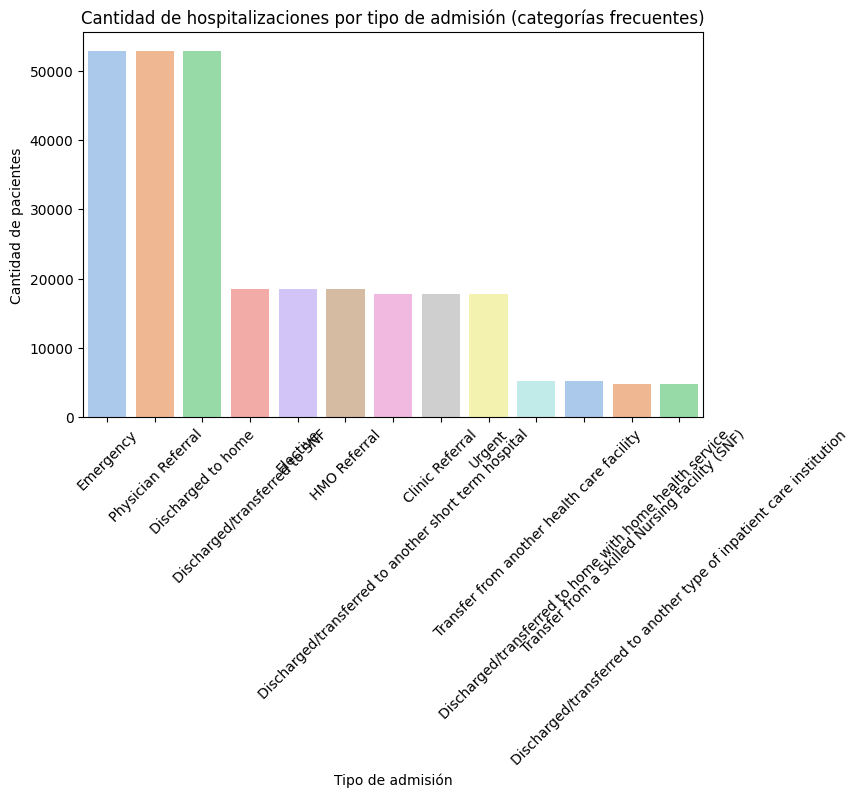

In [ ]:


# Visualizaciones de df_map_clean, lo tengo que unir con el anterior

df_data_map = df_data_clean.merge(df_map_clean, on='admission_type_id', how='left')

# Contar cuantos pacientes hay por cada tipo de admision
admission_counts = df_data_map['description'].value_counts()
admission_counts

# Para visualizar que tipo de admision es mas frecuente
# Filtrar solo categorías con más de 1000 pacientes
admission_counts_filtered = admission_counts[admission_counts > 1000]

# Graficar
plt.figure(figsize=(8,5))
sns.barplot(x=admission_counts_filtered.index, y=admission_counts_filtered.values, palette='pastel')
plt.xticks(rotation=45)
plt.title('Cantidad de hospitalizaciones por tipo de admisión (categorías frecuentes)')
plt.ylabel('Cantidad de pacientes')
plt.xlabel('Tipo de admisión')
plt.show()



/tmp/ipython-input-3729254978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_time_admission.index, y=avg_time_admission.values, palette='coolwarm')


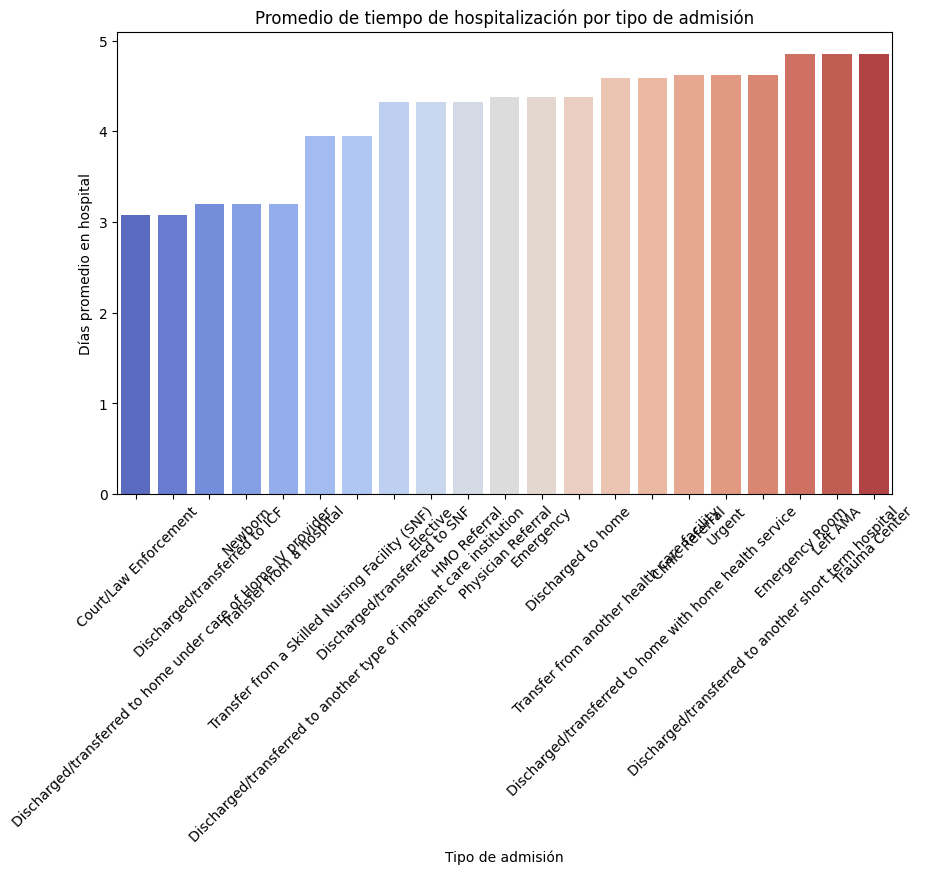

In [ ]:
# Promedio de tiempo en el hospital por tipo de admision

# Merge con el diccionario de admisiones
df_viz = df_data_clean.merge(df_map_clean, on='admission_type_id', how='left')

# Promedio de tiempo en el hospital por tipo de admisión
avg_time_admission = df_viz.groupby('description')['time_in_hospital'].mean().sort_values()

# Barplot del promedio de tiempo de hospitalización
plt.figure(figsize=(10,6))
sns.barplot(x=avg_time_admission.index, y=avg_time_admission.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Promedio de tiempo de hospitalización por tipo de admisión')
plt.ylabel('Días promedio en hospital')
plt.xlabel('Tipo de admisión')
plt.show()



readmitted
NO     53.588695
>30    35.185390
<30    11.225915
Name: proportion, dtype: float64


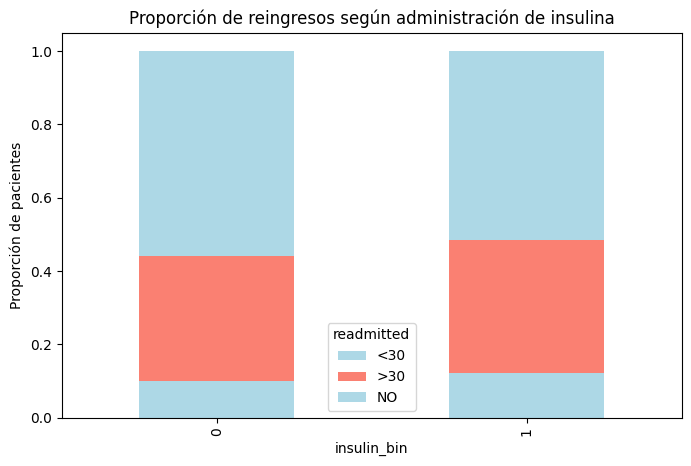

/tmp/ipython-input-3965405168.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_readmit = df_data_clean.groupby('age')['readmitted'].value_counts(normalize=True).unstack()


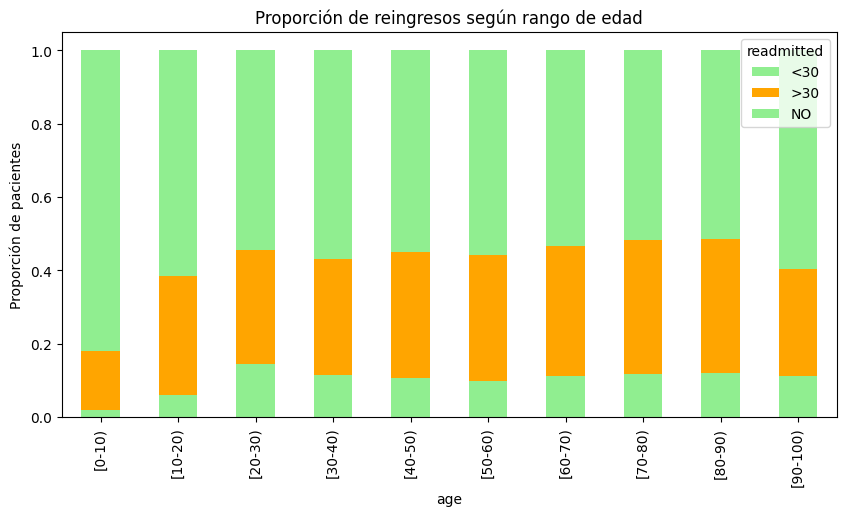

In [ ]:
# Analisis de reingresos hospitalarios

# Porcentaje de reingresos
readmit_counts = df_data_clean['readmitted'].value_counts(normalize=True) * 100
print(readmit_counts)

# Reingresos por tipo de tratamiento (por insulina binaria)
treatment_readmit = df_data_clean.groupby('insulin_bin')['readmitted'].value_counts(normalize=True).unstack()
treatment_readmit.plot(kind='bar', stacked=True, figsize=(8,5), color=['lightblue','salmon'])
plt.title('Proporción de reingresos según administración de insulina')
plt.ylabel('Proporción de pacientes')
plt.show()

# Reingresos por rango de edad
age_readmit = df_data_clean.groupby('age')['readmitted'].value_counts(normalize=True).unstack()
age_readmit.plot(kind='bar', stacked=True, figsize=(10,5), color=['lightgreen','orange'])
plt.title('Proporción de reingresos según rango de edad')
plt.ylabel('Proporción de pacientes')
plt.show()


In [ ]:
# Exporto mis dataset limpios

# Exportar df_data_clean
df_data_clean.to_csv('df_data_clean.csv', index=False)

# Exportar df_map_clean
df_map_clean.to_csv('df_map_clean.csv', index=False)

# Los descargo a mi PC

from google.colab import files

# Descargar df_data_clean
files.download('df_data_clean.csv')

# Descargar df_map_clean
files.download('df_map_clean.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>